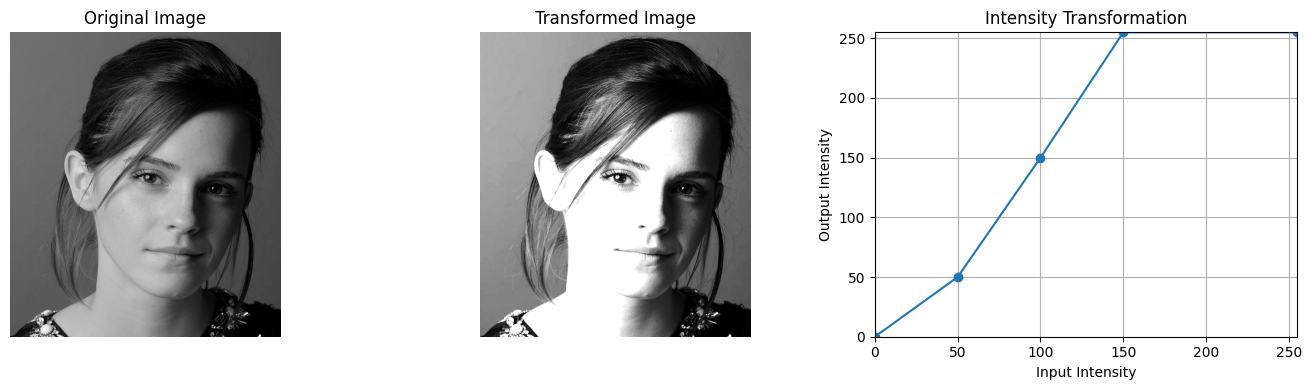

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def intensity_transform(im, breakpoints):
    """
    Apply a piecewise-linear intensity transformation.

    Parameters:
        im          : input grayscale image
        breakpoints : Nx2 array containing [input, output] points

    Returns:
        g : transformed image
        t : lookup table
    """

    # Create lookup table
    t = np.zeros(256, dtype=np.uint8)

    # Generate each piecewise-linear segment
    for i in range(len(breakpoints) - 1):

        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        # Input intensity values
        x = np.arange(x1, x2 + 1)

        # Linear interpolation
        y = y1 + (y2 - y1) * (x - x1) / (x2 - x1)

        # Store in LUT
        t[x] = np.round(y).astype(np.uint8)

    # Transform image
    g = t[im]

    return g, t


# --------------------------------------------------
# Read image
# --------------------------------------------------

f = cv.imread('images/emma.jpeg', cv.IMREAD_GRAYSCALE)

if f is None:
    raise FileNotFoundError("Image not found")


# --------------------------------------------------
# Breakpoints given in the question
# --------------------------------------------------

breakpoints = np.array([
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
])


# --------------------------------------------------
# Apply transformation
# --------------------------------------------------

g, t = intensity_transform(f, breakpoints)


# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(1, 3, figsize=(14, 4))


# Original image
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')


# Transformed image
ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Transformed Image')
ax[1].axis('off')


# --------------------------------------------------
# Transformation function
# --------------------------------------------------

# Plot the piecewise-linear transformation
ax[2].plot(
    breakpoints[:, 0],
    breakpoints[:, 1],
    'o-'
)

ax[2].set_title('Intensity Transformation')
ax[2].set_xlabel('Input Intensity')
ax[2].set_ylabel('Output Intensity')

ax[2].set_xlim(0, 255)
ax[2].set_ylim(0, 255)

ax[2].grid(True)


plt.tight_layout()
plt.show()